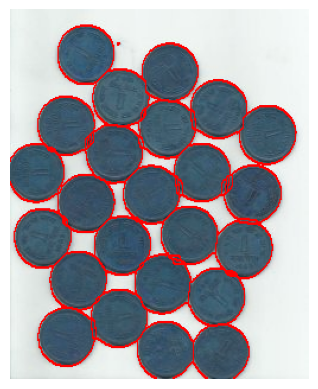

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import cv2
import os
import csv

from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from collections import Counter
from scipy.spatial import distance
from scipy.spatial import distance_matrix
from scipy.spatial.distance import pdist, squareform

import time

def showimage(image, title_=None, cmap_=None, save=None, savepath=None):
    plt.imshow(image, cmap=cmap_)
    plt.title(title_)
    plt.axis("off")
    if save:
        plt.savefig(savepath)
    plt.show()

def save_csv(savedata, savepath):
    np.savetxt(savepath, savedata, delimiter=",", fmt="%d")

def load_csv(filepath):
    return np.loadtxt(filepath, delimiter=",", dtype=np.int32)

def load_manual_markers(filepath):
    return load_csv(r"../Watershed/result\skimage_markers_.csv")

# watershedを実行して、可視化する。表示するものはmarkers, label, 統合させたもの
def show_result(markers, distance, thresh):
    # マーカーの可視化用
    mask_temp = markers.copy()
    mask_temp = mask_temp.astype(np.uint8) * 255
    # watershedの実行
    labels = watershed(-distance, markers, mask=thresh)
    # マーカーとラベルと統合して表示させる
    mask_on_labels = labels.copy()
    mask_on_labels[markers >= 1] = 255
    if False:
        fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
        ax = axes.ravel()
        ax[0].imshow(mask_temp)
        ax[0].set_title("markers")
        ax[1].imshow(labels)
        ax[1].set_title("labels")
        ax[1].imshow(labels)
        ax[2].imshow(mask_on_labels)
        ax[2].set_title("mask_on_labels")
        for a in ax:
            a.set_axis_off()
        fig.tight_layout()
        plt.show()
    return mask_on_labels, labels, mask_temp

# マーカーのシード値を修正する
# 距離計算して閾値以下を省く
def edit_seed(markers):
    # 0以外の座標を抽出（y, x の順）
    coords_yx = np.argwhere(markers != 0)
    # (x, y) 順に変換
    coords = coords_yx[:, [1, 0]]
    # ユークリッド距離の計算
    distances = pdist(coords, metric='euclidean')
    dist_matrix = squareform(distances)
    #save_csv(dist_matrix, r"../Watershed/Result/seed_dist_matrix.csv")
    # 各点の最小距離を求める
    nearest_dists = []
    nearest_info = []
    for i in range(len(coords)):
        non_self = np.where(dist_matrix[i] > 0, dist_matrix[i], np.inf)
        min_index = np.argmin(non_self)
        nearest_dists.append(dist_matrix[i, min_index])
        # [座標、最近傍座標、距離]で保存
        nearest_info.append((coords[i], coords[min_index], dist_matrix[i, min_index]))
    # 不必要なシードを削除する
    nearest_dists = np.array(nearest_dists)
    sorted_indices = np.argsort(nearest_dists)[::-1]  # 距離でソート
    top_24_indices = sorted_indices[:24]  # 上位24個のインデックスを取得

    for i in range(len(coords)):
        y, x = coords[i][1], coords[i][0]
        if i not in top_24_indices:  # 上位24個以外のマーカーを削除
            markers[y, x] = 0

    # 0以外のマーカーの数をカウント
    print(np.count_nonzero(markers))
    return markers

# 一度waaterhedを実行して、書くオブジェクトの個数を数える
def count_objects(markers, distance, thresh):
    # まずはwatershedを実行して、ラベルを取得
    labels = watershed(-distance, markers, mask=thresh)
    # ラベルのユニークな値を取得
    unique_labels = np.unique(labels)
    # それぞれの個数を数える
    counter = []
    for label in unique_labels:
        if label == 0:
            continue
        count = np.sum(labels == label)
        counter.append((label, count))

    # ピクセル数のリストを作成
    pixel_counts = np.array([c[1] for c in counter])
    mean = np.mean(pixel_counts)  # 平均
    # 平均以上のものを採用
    new_labels = [c for c in counter if c[1] >= mean]
    # new_labelに対応したマーカーだけ残して、あとは削除する
    new_markers = np.zeros_like(markers)
    for label, count in new_labels:
        new_markers[markers == label] = label
    return new_markers

jpg_path = r"..\Watershed/Image/water_coins.jpg"
image = cv2.imread(jpg_path)
image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
ret, thresh = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
# Now we want to separate the two objects in image
# Generate the markers as local maxima of the distance to the background
distance = ndi.distance_transform_edt(thresh)
coords = peak_local_max(distance, footprint=np.ones((3, 3)), labels=thresh)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
# 手動のマーカーをインプットしてみる
#markers = edit_seed(markers)
#showimage(markers)
#markers = count_objects(markers, distance, thresh)
mask_on_labels, labels, mask_temp = show_result(markers, distance, thresh)

# データの保存や表示
#showimage(mask_on_labels, "mask_on_labels", cmap_="gray", save=True, savepath=r"../Watershed/Result/skimage_mask_on_labels.png")

# 輪郭をとる
# 周囲を探索して自身と異なる値であれば-1を付与する?
Width, Height = labels.shape # W:X, H:Y
for h in range(Height):
    for w in range(Width):
        if labels[w, h] == -1:
            continue
        for dh in [-1, 0, 1]:
            for dw in [-1, 0, 1]:
                nh, nw = h + dh, w + dw
                if 0 <= nh < Height and 0 <= nw < Width:
                    if labels[w, h] != labels[nw, nh] and labels[nw, nh] != -1:
                        labels[w, h] = -1

labels[labels == -1] = 255
test = image.copy()
test[labels == 255] = [255, 0, 0]  # 赤色で輪郭を表示

showimage(test)